## model v11.0 ( bản theo kênh màu xám )


In [ ]:
# -- coding: utf-8 --
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image, ImageOps
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix as _cm_fn
import seaborn as _sns
import logging
from datetime import datetime
import timm
import torchvision.transforms as transforms
from collections import Counter
import matplotlib.pyplot as plt
import cv2


# ================================================================
# SMART FACE CLAHE
# ================================================================
class SmartFaceCLAHE:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)

    def __call__(self, img):
        if not isinstance(img, Image.Image):
            return img
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l_adjusted = self.clahe.apply(l)
        lab_adjusted = cv2.merge((l_adjusted, a, b))
        img_normalized = cv2.cvtColor(lab_adjusted, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_normalized)


def categorize_pain(score):
    if score < 2.0:
        return 0
    elif score < 4.0:
        return 1
    return 2


PAIN_LABELS = ["Low", "Medium", "High"]


# === CẤU HÌNH V11 ===
class Config:
    DATA_ROOT_DIR = "dataset_osfstorage-archive/Stimuli"
    LABELS_PATH = "dataset_osfstorage-archive/NormingData/DFD_NormingData.csv"
    SKIN_COLOR_BASE = os.path.join("dataset_osfstorage-archive", "Color Skin")

    BATCH_SIZE = 16
    IMG_SIZE = 300
    LEARNING_RATE = 5.0e-4
    EPOCHS_KFOLD = 50
    K_FOLDS = 10
    TEST_SPLIT = 0.15

    EARLY_STOPPING_PATIENCE = 15
    CONFIDENCE_THRESHOLD = 0.8
    BELIEVABILITY_THRESHOLD = 2.5
    BACKBONE = 'efficientnet_b3'
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42
    WARMUP_EPOCHS = 5
    RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d_%H-%M-%S') + "_GRAY_PureRaw_Baseline"
    NUM_WORKERS = 4


cfg = Config()


# === HÀM BỔ TRỢ ===
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True


def custom_collate(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if not batch:
        return None
    imgs = torch.stack([x[0] for x in batch])
    labels = torch.stack([x[1] for x in batch])
    groups = [x[2] for x in batch]
    return imgs, labels, groups


def calculate_weights(dataset_list, logger):
    """
    Tính class weight theo group (race × gender) cho weighted loss.
    """
    groups = [item['group'] for item in dataset_list]
    count = Counter(groups)
    total = len(groups)
    n_cls = len(count)
    weights = {}

    logger.info("\n--- WEIGHT cho từng NHÓM (WEIGHTED LOSS — Fairness) ---")
    for group, freq in sorted(count.items()):
        w = total / (n_cls * freq)
        weights[group] = w
        logger.info(f"  Nhóm {group:<20}: {freq:<4} mẫu -> Weight: {w:.4f}")
    return weights


def save_split_filenames(indices, dataset, split_name, fold_path):
    os.makedirs(fold_path, exist_ok=True)
    txt_path = os.path.join(fold_path, f"{split_name}_list.txt")
    with open(txt_path, 'w', encoding='utf-8') as f:
        for idx in indices:
            item = dataset.data_list[idx]
            f.write(f"{os.path.basename(item['path'])} | {item['label']:.4f} | {item['group']}\n")


# === DATASET ===
class PainDataset(Dataset):
    def __init__(self, config):
        self.cfg = config
        self.image_path_map = self._create_smart_file_map(self.cfg.DATA_ROOT_DIR)
        self.skin_color_map = self._create_skin_color_map(self.cfg.SKIN_COLOR_BASE)

        df = pd.read_csv(self.cfg.LABELS_PATH)
        df.columns = df.columns.str.strip()
        cols = ['Pain_Expression', 'PhysicalPain_Neutral', 'HowBelievable', 'OpenFace_confidence',
                'White', 'Black', 'Hispanic', 'EastAsian', 'SouthAsian', 'Male', 'Female']
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

        if 'OpenFace_confidence' in df.columns:
            df = df[df['OpenFace_confidence'] >= self.cfg.CONFIDENCE_THRESHOLD]
        if 'HowBelievable' in df.columns:
            df = df[df['HowBelievable'].fillna(9.0) >= self.cfg.BELIEVABILITY_THRESHOLD]

        self.data_list = []
        self.stratify_labels = []

        for _, row in df.iterrows():
            target = str(row['Target']).strip()
            base_name = os.path.splitext(target)[0].lower()
            clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')

            actual_key = None
            if clean_name in self.image_path_map:
                actual_key = clean_name
            elif (clean_name + "_earring") in self.image_path_map:
                actual_key = clean_name + "_earring"

            if actual_key is None:
                continue
            if actual_key not in self.skin_color_map:
                continue

            full_path = self.image_path_map[actual_key]

            p_val = row['Pain_Expression']
            n_val = row['PhysicalPain_Neutral']
            if not pd.isna(p_val):
                label = float(p_val)
            elif not pd.isna(n_val):
                label = float(n_val)
            else:
                label = 0.0

            race = self.skin_color_map[actual_key]
            gender = "Male" if row.get('Male') == 1 else "Female"
            group_id = f"{race}_{gender}"

            self.data_list.append({'path': full_path, 'label': label, 'group': group_id, 'race': race})
            self.stratify_labels.append(group_id)

    def _create_smart_file_map(self, root_dir):
        file_map = {}
        for dirpath, _, filenames in os.walk(root_dir):
            for f in filenames:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    base_name = os.path.splitext(f)[0].lower()
                    clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')
                    if "cropped" in dirpath.lower() or clean_name not in file_map:
                        file_map[clean_name] = os.path.join(dirpath, f)
        return file_map

    def _create_skin_color_map(self, skin_base):
        color_map = {}
        if not os.path.exists(skin_base):
            return color_map
        mapping = {'black': 'Black', 'white': 'White', 'yellow': 'Asian'}
        for folder, label in mapping.items():
            folder_path = os.path.join(skin_base, folder)
            if os.path.exists(folder_path):
                for f in os.listdir(folder_path):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                        base_name = os.path.splitext(f)[0].lower()
                        clean_name = base_name.replace('_cropped', '').replace('_standardized', '').replace('_unedited', '')
                        color_map[clean_name] = label
        return color_map

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        try:
            img = ImageOps.exif_transpose(Image.open(item['path'])).convert("RGB")
            return img, torch.tensor(item['label'], dtype=torch.float), item['group']
        except Exception as e:
            logging.warning(f"[DataError] {item['path']} | {e}")
            return None


class SplitTransformDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base.data_list[idx]
        try:
            img = ImageOps.exif_transpose(Image.open(item['path'])).convert("RGB")
            if self.transform:
                img = self.transform(img)
            return img, torch.tensor(item['label'], dtype=torch.float), item['group']
        except Exception as e:
            logging.warning(f"[DataError] {item['path']} | {e}")
            return None


# === MODEL ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=True, num_classes=0, global_pool='avg')
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, 1)
        )

    def forward(self, x):
        return self.pain_head(self.backbone(x))


# === WARMUP + COSINE SCHEDULER ===
class WarmupCosineAnnealingLR:
    def __init__(self, optimizer, warmup_epochs, total_epochs):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = optimizer.defaults['lr']
        self.epoch = 0

    def step(self):
        if self.epoch < self.warmup_epochs:
            lr = self.base_lr * (self.epoch + 1) / self.warmup_epochs
        else:
            progress = (self.epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.base_lr * (1 + np.cos(np.pi * progress)) / 2
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        self.epoch += 1


# === MAIN TRAINING FUNCTION ===
def main(config):
    seed_everything(config.SEED)

    export_base = os.path.join("exported_data", config.RUN_TIMESTAMP)
    os.makedirs(export_base, exist_ok=True)
    log_file_path = os.path.join(export_base, "training_log.txt")

    logger = logging.getLogger('root')
    logger.setLevel(logging.INFO)
    logger.handlers = []

    c_handler = logging.StreamHandler()
    f_handler = logging.FileHandler(log_file_path, mode='w', encoding='utf-8')
    formatter = logging.Formatter('%(message)s')
    c_handler.setFormatter(formatter)
    f_handler.setFormatter(formatter)
    logger.addHandler(c_handler)
    logger.addHandler(f_handler)

    clahe = SmartFaceCLAHE(clip_limit=2.0, tile_grid_size=(8, 8))

    train_transform = transforms.Compose([
        clahe,
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.449, 0.449, 0.449], std=[0.226, 0.226, 0.226])
    ])
    eval_transform = transforms.Compose([
        clahe,
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.449, 0.449, 0.449], std=[0.226, 0.226, 0.226])
    ])

    full_dataset = PainDataset(config)
    train_dataset = SplitTransformDataset(full_dataset, train_transform)
    eval_dataset = SplitTransformDataset(full_dataset, eval_transform)

    if len(full_dataset) == 0:
        logger.info("❌ Không có dữ liệu để huấn luyện!")
        return

    logger.info("\n" + "=" * 50)
    logger.info("🚀 BẮT ĐẦU HUẤN LUYỆN MODEL V11 (GRAY BASELINE | FAIRNESS-ALIGNED)")
    logger.info("=" * 50)
    logger.info(f"🖥️ Thiết bị sử dụng: {str(config.DEVICE).upper()}")
    logger.info(f"📂 Thư mục chạy: {config.RUN_TIMESTAMP}")
    logger.info(f"📊 Cấu hình: {config.K_FOLDS}-Folds | Test size: {config.TEST_SPLIT*100}%")
    logger.info(f"📁 Tổng số ảnh skin map (Black/White/Asian): {len(full_dataset.skin_color_map)}")
    logger.info(f"📈 Tổng cộng: {len(full_dataset)} ảnh phù hợp tiêu chí lọc.")
    logger.info("=" * 50)

    all_indices = np.arange(len(full_dataset))
    all_labels = np.array(full_dataset.stratify_labels)

    counts = Counter(all_labels)
    rare_groups = [g for g, c in counts.items() if c < 2]
    if rare_groups:
        logger.info(f"⚠️ Cảnh báo: Các nhóm {rare_groups} chỉ có 1 mẫu. Sẽ loại bỏ để Stratify.")
        valid_mask = np.isin(all_labels, rare_groups, invert=True)
        all_indices = all_indices[valid_mask]
        all_labels = all_labels[valid_mask]

    train_val_idx, test_idx = train_test_split(
        all_indices, test_size=config.TEST_SPLIT,
        stratify=all_labels, random_state=config.SEED
    )

    train_val_data_list = [full_dataset.data_list[i] for i in train_val_idx]
    group_weights = calculate_weights(train_val_data_list, logger)

    test_loader = DataLoader(
        Subset(eval_dataset, test_idx),
        batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=custom_collate,
        num_workers=config.NUM_WORKERS, pin_memory=True
    )

    log_path = os.path.join(export_base, "skin_color_distribution.txt")

    def get_dist(indices):
        races = [full_dataset.data_list[i]['race'] for i in indices]
        count = Counter(races)
        total = len(indices)
        return {r: (c, c / total * 100) for r, c in count.items()}

    train_val_dist, test_dist = get_dist(train_val_idx), get_dist(test_idx)

    logger.info("\n🔍 PHÂN BỔ MÀU DA TRONG DỮ LIỆU:")
    logger.info(f"{'Nhóm':<15} | {'Train+Val (Count/%)':<25} | {'Test (Count/%)':<25}")
    logger.info("-" * 75)
    all_races = sorted(list(set(list(train_val_dist.keys()) + list(test_dist.keys()))))
    with open(log_path, 'w', encoding='utf-8') as f:
        f.write(f"--- THỐNG KÊ TỶ LỆ MÀU DA (RUN: {config.RUN_TIMESTAMP}) ---\n\n")
        header = f"{'Nhóm':<15} | {'Train+Val Count':<15} | {'Train %':<10} | {'Test Count':<12} | {'Test %':<10}\n"
        f.write(header + "-" * 75 + "\n")
        for r in all_races:
            tr_c, tr_p = train_val_dist.get(r, (0, 0))
            te_c, te_p = test_dist.get(r, (0, 0))
            line = f"{r:<15} | {tr_c:<15} | {tr_p:>7.2f}% | {te_c:<12} | {te_p:>7.2f}%"
            logger.info(line)
            f.write(line + "\n")
    logger.info("-" * 75)
    logger.info(f"✅ Đã lưu log chi tiết vào: {log_path}\n")

    skf = StratifiedKFold(n_splits=config.K_FOLDS, shuffle=True, random_state=config.SEED)
    y_train_val = [full_dataset.stratify_labels[i] for i in train_val_idx]
    fold_results = []

    for fold, (train_fold_rel_idx, val_fold_rel_idx) in enumerate(skf.split(train_val_idx, y_train_val)):
        logger.info(f"\n=== FOLD {fold+1}/{config.K_FOLDS} ===")
        fold_export_path = os.path.join(export_base, f"fold_{fold+1}")

        train_ids = train_val_idx[train_fold_rel_idx]
        val_ids = train_val_idx[val_fold_rel_idx]

        save_split_filenames(train_ids, full_dataset, "train", fold_export_path)
        save_split_filenames(val_ids, full_dataset, "val", fold_export_path)
        save_split_filenames(test_idx, full_dataset, "test", fold_export_path)

        train_loader = DataLoader(
            Subset(train_dataset, train_ids),
            batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=custom_collate,
            num_workers=config.NUM_WORKERS, pin_memory=True
        )
        val_loader = DataLoader(
            Subset(eval_dataset, val_ids),
            batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=custom_collate,
            num_workers=config.NUM_WORKERS, pin_memory=True
        )

        model = BaselinePainModel(config).to(config.DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE)
        scheduler = WarmupCosineAnnealingLR(
            optimizer, warmup_epochs=config.WARMUP_EPOCHS, total_epochs=config.EPOCHS_KFOLD
        )

        best_val_loss = float('inf')
        patience_counter = 0

        checkpoint_path = os.path.join("checkpoints", f"{config.RUN_TIMESTAMP}_fold_{fold+1}.pth")
        os.makedirs("checkpoints", exist_ok=True)

        for epoch in range(config.EPOCHS_KFOLD):
            model.train()
            train_loss = 0.0
            for batch_data in train_loader:
                if batch_data is None:
                    continue
                imgs, labels, batch_groups = batch_data
                imgs, labels = imgs.to(config.DEVICE), labels.to(config.DEVICE)

                preds = model(imgs).squeeze(-1)
                batch_w = torch.tensor(
                    [group_weights[g] for g in batch_groups],
                    dtype=preds.dtype, device=config.DEVICE
                )
                loss = ((preds - labels) ** 2 * batch_w).mean()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_data in val_loader:
                    if batch_data is None:
                        continue
                    imgs, labels, _ = batch_data
                    imgs, labels = imgs.to(config.DEVICE), labels.to(config.DEVICE)
                    val_loss += nn.functional.mse_loss(model(imgs).squeeze(-1), labels).item()

            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            current_lr = optimizer.param_groups[0]['lr']

            logger.info(f" Ep {epoch+1:02d} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                torch.save(model.state_dict(), checkpoint_path)
            else:
                patience_counter += 1
                if patience_counter >= config.EARLY_STOPPING_PATIENCE:
                    logger.info("Early stopping triggered!")
                    break
            scheduler.step()

        model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE, weights_only=True))
        model.eval()
        all_labels_t, all_preds_t = [], []
        with torch.no_grad():
            for batch_data in val_loader:
                if batch_data is None:
                    continue
                imgs, labels, _ = batch_data
                preds = model(imgs.to(config.DEVICE)).squeeze(-1)
                all_labels_t.extend(labels.cpu().numpy())
                all_preds_t.extend(preds.cpu().numpy())

        r2 = r2_score(all_labels_t, all_preds_t)
        rmse = np.sqrt(mean_squared_error(all_labels_t, all_preds_t))
        mae = mean_absolute_error(all_labels_t, all_preds_t)

        fold_results.append({'fold': fold+1, 'val_r2': r2, 'val_rmse': rmse, 'val_mae': mae})
        logger.info(f"-> Fold {fold+1} Validation | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(all_labels_t, all_preds_t, alpha=0.5, s=20, color='steelblue', label='Samples')
        _min = min(min(all_labels_t), min(all_preds_t))
        _max = max(max(all_labels_t), max(all_preds_t))
        ax.plot([_min, _max], [_min, _max], 'r--', linewidth=1.5, label='Perfect fit')
        ax.set_xlabel("Actual Pain Score")
        ax.set_ylabel("Predicted Pain Score")
        ax.set_title(f"Fold {fold+1} | R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        scatter_path = os.path.join(export_base, f"scatter_fold_{fold+1}.png")
        fig.savefig(scatter_path, bbox_inches="tight")
        plt.close(fig)

        _labels = PAIN_LABELS
        _yt = [categorize_pain(x) for x in all_labels_t]
        _yp = [categorize_pain(x) for x in all_preds_t]

        _cm = _cm_fn(_yt, _yp, labels=[0, 1, 2])
        _rs = _cm.sum(axis=1, keepdims=True)
        _cmr = np.divide(_cm.astype(float), _rs, out=np.zeros_like(_cm, dtype=float), where=_rs != 0)
        _off = _cm.copy()
        np.fill_diagonal(_off, 0)
        _mi = np.unravel_index(_off.argmax(), _off.shape)
        _worst = (f"⚠  Nhầm: '{_labels[_mi[0]]}' → '{_labels[_mi[1]]}' ({_off[_mi]} lần)"
                  if _off[_mi] > 0 else "✓  OK")

        cm_fig, cm_axes = plt.subplots(1, 2, figsize=(13, 5))
        cm_fig.patch.set_facecolor("#1a1a2e")
        for _ax, _data, _fmt, _cmap, _sub in [
            (cm_axes[0], _cm,  "d",    _sns.color_palette(["#2d2b55","#4a4080","#9b59b6","#ff79c6"], as_cmap=True), "Count"),
            (cm_axes[1], _cmr, ".2f",  "YlGn", "Recall"),
        ]:
            _ax.set_facecolor("#16213e")
            _tc = "white" if _sub == "Count" else "#1a1a2e"
            _sns.heatmap(_data, annot=True, fmt=_fmt, cmap=_cmap,
                         xticklabels=_labels, yticklabels=_labels,
                         linewidths=0.5, linecolor="#2d2b55", cbar=False, ax=_ax,
                         annot_kws={"size": 16, "weight": "bold", "color": _tc})
            _ax.set_xlabel("Predicted", color="white", fontsize=12)
            _ax.set_ylabel("Actual",    color="white", fontsize=12)
            _ax.set_title(f"{_sub} – Fold {fold+1}", color="white", fontsize=13, fontweight="bold")
            _ax.tick_params(colors="white")
        cm_fig.text(0.5, -0.04, _worst, ha="center", color="#ff6b6b", fontsize=11)
        plt.tight_layout()
        cm_path = os.path.join(export_base, f"cm_fold_{fold+1}.png")
        cm_fig.savefig(cm_path, bbox_inches="tight")
        plt.close(cm_fig)

    logger.info("\n" + "=" * 80)
    logger.info(f"ENSEMBLE TEST EVALUATION ({config.K_FOLDS} folds -> đánh giá 1 lần duy nhất)")
    logger.info("=" * 80)

    checkpoint_paths_all = [
        os.path.join("checkpoints", f"{config.RUN_TIMESTAMP}_fold_{i+1}.pth")
        for i in range(config.K_FOLDS)
    ]

    ensemble_models = []
    for cp in checkpoint_paths_all:
        if os.path.exists(cp):
            m = BaselinePainModel(config).to(config.DEVICE)
            m.load_state_dict(torch.load(cp, map_location=config.DEVICE, weights_only=True))
            m.eval()
            ensemble_models.append(m)
        else:
            logger.info(f"[WARN] Không tìm thấy checkpoint: {cp}")

    logger.info(f"Đã load {len(ensemble_models)}/{config.K_FOLDS} fold checkpoints cho ensemble")

    if len(ensemble_models) == 0:
        logger.info("❌ Không có checkpoint nào để ensemble test.")
    else:
        all_labels_test, all_preds_test = [], []
        with torch.no_grad():
            for batch_data in test_loader:
                if batch_data is None:
                    continue
                imgs, labels, _ = batch_data
                imgs = imgs.to(config.DEVICE)
                fold_preds = [m(imgs).squeeze(-1).cpu().numpy() for m in ensemble_models]
                ensemble_pred = np.mean(fold_preds, axis=0)
                all_labels_test.extend(labels.numpy())
                all_preds_test.extend(ensemble_pred.tolist())

        test_r2 = r2_score(all_labels_test, all_preds_test)
        test_rmse = np.sqrt(mean_squared_error(all_labels_test, all_preds_test))
        test_mae = mean_absolute_error(all_labels_test, all_preds_test)

        logger.info(f"ENSEMBLE TEST | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}")

        fig, ax = plt.subplots(figsize=(7, 7))
        ax.scatter(all_labels_test, all_preds_test, alpha=0.5, s=25, color='darkorange', label='Ensemble Samples')
        _mn = min(min(all_labels_test), min(all_preds_test))
        _mx = max(max(all_labels_test), max(all_preds_test))
        ax.plot([_mn, _mx], [_mn, _mx], 'r--', linewidth=1.5, label='Perfect fit')
        ax.set_xlabel("Actual Pain Score")
        ax.set_ylabel("Predicted Pain Score")
        ax.set_title(f"ENSEMBLE TEST | R²={test_r2:.3f}  RMSE={test_rmse:.3f}  MAE={test_mae:.3f}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        scatter_path = os.path.join(export_base, "scatter_ensemble_test.png")
        fig.savefig(scatter_path, bbox_inches="tight")
        plt.close(fig)
        logger.info(f"✅ Đã lưu biểu đồ ensemble test tại: {scatter_path}")

    results_df = pd.DataFrame(fold_results)
    if not results_df.empty:
        mean_r2 = results_df['val_r2'].mean()
        std_r2 = results_df['val_r2'].std()
        mean_rmse = results_df['val_rmse'].mean()
        std_rmse = results_df['val_rmse'].std()
        mean_mae = results_df['val_mae'].mean()
        std_mae = results_df['val_mae'].std()

        best_fold = results_df.loc[results_df['val_r2'].idxmax()]

        logger.info("\n" + "="*80)
        logger.info(f"--- V11 FINAL RESULTS ({config.K_FOLDS}-Fold Stratified) ---")
        logger.info("="*80)
        logger.info(f"{'fold':>6} {'r2':>15} {'rmse':>15} {'mae':>15}")

        for _, row in results_df.iterrows():
            logger.info(f"{int(row['fold']):>6} {row['val_r2']:>15.6f} {row['val_rmse']:>15.6f} {row['val_mae']:>15.6f}")

        logger.info("")
        logger.info(f"Mean RMSE: {mean_rmse:.4f} (±{std_rmse:.4f})")
        logger.info(f"Mean MAE : {mean_mae:.4f} (±{std_mae:.4f})")
        logger.info(f"Mean R²  : {mean_r2:.4f} (±{std_r2:.4f})")
        logger.info(f"🏆 Best Fold: Fold {int(best_fold['fold'])} (R²: {best_fold['val_r2']:.4f}, RMSE: {best_fold['val_rmse']:.4f})")
        logger.info("")

        logger.info("v11 Improvements Target:")
        r2_check = "✓" if mean_r2 >= 0.68 else "x"
        rmse_check = "✓" if mean_rmse <= 0.62 else "x"
        std_check = "✓" if std_r2 <= 0.04 else "x"

        logger.info(f"{r2_check}   V10 Mean R²: 0.6106   -> V11 Target: ≥0.68-0.70  | Đạt được: {mean_r2:.4f}")
        logger.info(f"{rmse_check} V10 Mean RMSE: 0.6823 -> V11 Target: ≤0.60-0.62 | Đạt được: {mean_rmse:.4f}")
        logger.info(f"{std_check}  V10 Std Dev: ±7%      -> V11 Target: ±3-4%       | Đạt được: ±{std_r2*100:.2f}%")
        logger.info("="*80)
        logger.info(f"✅ HOÀN TẤT! File log được lưu tại: {log_file_path}")


if __name__ == '__main__':
    if sys.platform == "win32":
        cfg.NUM_WORKERS = 0
    main(cfg)


🚀 BẮT ĐẦU HUẤN LUYỆN MODEL V11 (PURE RAW BASELINE)
🖥️ Thiết bị sử dụng: CUDA
📂 Thư mục chạy: 2026-04-12_09-37-49_GRAY_PureRaw_Baseline
📊 Cấu hình: 10-Folds | Test size: 15.0%
📁 Tổng số ảnh trong 3 folder (Black/White/Yellow): 652
📈 Tổng cộng: 645 ảnh phù hợp tiêu chí lọc.

🔍 PHÂN BỔ MÀU DA TRONG DỮ LIỆU:
Nhóm            | Train+Val (Count/%)       | Test (Count/%)           
---------------------------------------------------------------------------
Black           | 149             |   27.19% | 26           |   26.80%
White           | 314             |   57.30% | 56           |   57.73%
Yellow          | 85              |   15.51% | 15           |   15.46%
---------------------------------------------------------------------------
✅ Đã lưu log chi tiết vào: exported_data\2026-04-12_09-37-49_GRAY_PureRaw_Baseline\skin_color_distribution.txt


=== FOLD 1/10 ===
Loading pretrained weights from Hugging Face hub (timm/efficientnet_b3.ra2_in1k)
[timm/efficientnet_b3.ra2_in1k] Safe alterna

KeyboardInterrupt: 

## Script test model v11 với ENSEMBLE 10 FOLDS từ file test_list.txt

Script này test model V11 sử dụng ensemble của 10 folds mới nhất, đọc danh sách ảnh từ file test_list.txt trong exported_data, và tính toán metrics. Ảnh nằm trong các folder con của "Expression Images/Cropped and Standardized".


In [ ]:
# -*- coding: utf-8 -*-
"""
Script kiểm tra Model V11 - Test từ file test_list.txt với ENSEMBLE 10 FOLDS
"""
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
import timm
import os
import glob
from sklearn.metrics import mean_squared_error, mean_absolute_error

# cấu hình xử lý màu ảnh theo Median Face Luminance
import cv2
import numpy as np
from PIL import Image
class SmartFaceCLAHE:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        """
        Dùng CLAHE (Contrast Limited Adaptive Histogram Equalization)
        để cân bằng sáng mà không làm mất đi độ tương phản của các nếp nhăn
        và đặc trưng đau trên khuôn mặt.
        """
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        
    def __call__(self, img):
        if not isinstance(img, Image.Image): return img
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        # Áp dụng CLAHE lên kênh sáng L
        l_adjusted = self.clahe.apply(l)
        
        lab_adjusted = cv2.merge((l_adjusted, a, b))
        img_normalized = cv2.cvtColor(lab_adjusted, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_normalized)

# === 1. CẤU HÌNH ===
class Config:
    BACKBONE = 'efficientnet_b3' 
    IMG_SIZE = 300                
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Ensemble 10 folds
    # V11_CHECKPOINT_PATTERN = "checkpoints/2026-03-30_18-59-41_GRAY_MedianFaceLuminance_V11_Fairness_fold_*.pth"
    V11_CHECKPOINT_PATTERN = "checkpoints/2026-03-29_15-40-22_GRAY_MedianFaceLuminance_V11_Fairness_fold_*.pth"

    # File test_list.txt (dùng fold_1, giả sử giống nhau)
    TEST_LIST_PATH = "exported_data/2026-03-29_15-40-22_GRAY_MedianFaceLuminance_V11_Fairness/fold_1/test_list.txt"
    
    # Base path cho ảnh - SỬ DỤNG FOLDER COLOR SKIN
    IMAGE_BASE_PATH = r"D:\DATA\Code\DelawarePain\dataset_osfstorage-archive\Stimuli\Expression Images\Corlor Skin"

cfg = Config()

# === 2. KIẾN TRÚC MODEL ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=False, num_classes=0, global_pool='avg')
        # V11: Dropout(0.3)
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, 1)
        )

    def forward(self, x):
        return self.pain_head(self.backbone(x))

# === 3. HÀM DỰ ĐOÁN ENSEMBLE ===
def predict_pain_level_ensemble(image_path, checkpoint_paths, config):
    """Dự đoán ensemble từ 10 folds"""
    val_transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),  # Chuyển xám
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.449, 0.449, 0.449], std=[0.226, 0.226, 0.226])
    ])

    try:
        if not os.path.exists(image_path):
            print(f"⚠️  Không tìm thấy ảnh: {image_path}")
            return None

        # Xử lý ảnh
        img_pil = Image.open(image_path)
        img_pil = ImageOps.exif_transpose(img_pil)
        
        if img_pil.mode in ('RGBA', 'LA') or (img_pil.mode == 'P' and 'transparency' in img_pil.info):
            background = Image.new("RGB", img_pil.size, (200, 200, 200))
            background.paste(img_pil, mask=img_pil.convert('RGBA').split()[3])
            img_pil = background
        else:
            img_pil = img_pil.convert("RGB")

        img_tensor = val_transform(img_pil).unsqueeze(0).to(config.DEVICE)
        
        # Ensemble
        predictions = []
        for checkpoint_path in sorted(checkpoint_paths):
            if not os.path.exists(checkpoint_path):
                continue
                
            model = BaselinePainModel(config).to(config.DEVICE)
            model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
            model.eval()
            
            with torch.no_grad():
                pred = model(img_tensor).item()
                predictions.append(pred)
        
        if not predictions:
            return None
        
        ensemble_score = sum(predictions) / len(predictions)
        return ensemble_score

    except Exception as e:
        return None

# === 4. HÀM MAP GROUP ĐẾN FOLDER ===
def get_image_path(image_name):
    """Tìm ảnh trong 3 folder: black, white, yellow dựa trên tên file"""
    
    # Mapping từ prefix trong tên file sang folder
    # BF = Black Female, BM = Black Male -> black
    # WF = White Female, WM = White Male -> white  
    # AF = Asian Female, AM = Asian Male, LF = Latinx Female, LM = Latinx Male, OF = Other Female, OM = Other Male -> yellow
    
    if image_name.startswith('DPD_1_BF') or image_name.startswith('DPD_1_BM'):
        folder = 'black'
    elif image_name.startswith('DPD_1_WF') or image_name.startswith('DPD_1_WM'):
        folder = 'white'
    else:
        # AF, AM, LF, LM, OF, OM hoặc các trường hợp khác -> yellow
        folder = 'yellow'
    
    candidate_path = os.path.join(cfg.IMAGE_BASE_PATH, folder, image_name)
    
    if os.path.exists(candidate_path):
        return candidate_path
    
    # Fallback: tìm trong tất cả 3 folder
    for color_folder in ['black', 'white', 'yellow']:
        search_path = os.path.join(cfg.IMAGE_BASE_PATH, color_folder, image_name)
        if os.path.exists(search_path):
            return search_path
    
    return candidate_path  # Trả về path mặc dù không tồn tại

# === 5. MAIN ===
if __name__ == '__main__':
    print("🚀 Bắt đầu test model V11 với ENSEMBLE 10 FOLDS từ test_list.txt")
    print(f"📋 Test list: {cfg.TEST_LIST_PATH}")
    print("-" * 60)
    
    # Tìm tất cả checkpoints
    checkpoint_paths = glob.glob(cfg.V11_CHECKPOINT_PATTERN)
    if not checkpoint_paths:
        print(f"❌ Không tìm thấy checkpoints: {cfg.V11_CHECKPOINT_PATTERN}")
        exit()
    
    print(f"✅ Tìm thấy {len(checkpoint_paths)} checkpoints")
    
    # Đọc test_list.txt
    if not os.path.exists(cfg.TEST_LIST_PATH):
        print(f"❌ Không tìm thấy test_list.txt: {cfg.TEST_LIST_PATH}")
        exit()
    
    with open(cfg.TEST_LIST_PATH, 'r') as f:
        lines = f.readlines()
    
    print(f"📊 Số ảnh test: {len(lines)}")
    print("-" * 60)
    
    # Test từng ảnh
    results = []  # List để lưu kết quả: (image_name, true_pain, pred_pain, error)
    
    for line in lines:
        parts = line.strip().split(' | ')
        if len(parts) >= 2:  # Ít nhất image_name và true_pain
            image_name = parts[0]
            true_pain_str = parts[1]
            true_pain = float(true_pain_str)
        else:
            continue
        
        # Tìm đường dẫn ảnh từ tên ảnh
        image_path = get_image_path(image_name)
        
        # Dự đoán ensemble
        pred_pain = predict_pain_level_ensemble(image_path, checkpoint_paths, cfg)
        
        if pred_pain is not None:
            error = abs(pred_pain - true_pain)
            results.append((image_name, true_pain, pred_pain, error))
        else:
            print(f"❌ {image_name} | Dự đoán thất bại")
    
    # Sort results theo error giảm dần
    results.sort(key=lambda x: x[3], reverse=True)
    
    # In kết quả đã sort
    print("\n📋 KẾT QUẢ TEST (SORT THEO ERROR GIẢM DẦN):")
    print("-" * 80)
    for image_name, true_pain, pred_pain, error in results:
        print(f"🖼️  {image_name:<50} | True: {true_pain:.4f} | Pred: {pred_pain:.4f} | Error: {error:.4f}")
    
    # Tính metrics
    if results:
        true_labels = [r[1] for r in results]
        pred_labels = [r[2] for r in results]
        mse = mean_squared_error(true_labels, pred_labels)
        mae = mean_absolute_error(true_labels, pred_labels)
        
        print("-" * 80)
        print("📈 METRICS:")
        print(f"   • MSE: {mse:.4f}")
        print(f"   • MAE: {mae:.4f}")
        print(f"   • Số ảnh thành công: {len(results)}/{len(lines)}")
    else:
        print("❌ Không có dự đoán nào thành công!")

d:\miniconda\envs\myENV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Bắt đầu test model V11 với ENSEMBLE 10 FOLDS từ test_list.txt
📋 Test list: exported_data/2026-03-29_15-40-22_GRAY_MedianFaceLuminance_V11_Fairness/fold_1/test_list.txt
------------------------------------------------------------
✅ Tìm thấy 10 checkpoints
📊 Số ảnh test: 97
------------------------------------------------------------

📋 KẾT QUẢ TEST (SORT THEO ERROR GIẢM DẦN):
--------------------------------------------------------------------------------
🖼️  DPD_1_AM8_p2c.png                                  | True: 5.3000 | Pred: 3.6296 | Error: 1.6704
🖼️  DPD_1_WM5_p1.png                                   | True: 5.4103 | Pred: 3.8094 | Error: 1.6009
🖼️  DPD_1_WM10_p3.png                                  | True: 3.9268 | Pred: 2.5138 | Error: 1.4130
🖼️  DPD_1_LF11_p2c.png                                 | True: 2.8367 | Pred: 4.1868 | Error: 1.3501
🖼️  DPD_1_WM34_p5c.png                                 | True: 5.9556 | Pred: 4.6684 | Error: 1.2872
🖼️  DPD_1_BM8_p2c.png             

In [ ]:
# Thêm vào cuối test script
from collections import defaultdict

group_errors = defaultdict(list)
for line in lines:
    parts = line.strip().split(' | ')
    if len(parts) < 3: continue
    name, true_pain, group = parts[0], float(parts[1]), parts[2]
    image_path = get_image_path(name)
    pred = predict_pain_level_ensemble(image_path, checkpoint_paths, cfg)
    if pred is not None and np.isfinite(pred): group_errors[group].append(abs(pred - true_pain))

print("\n📊 FAIRNESS ANALYSIS:")
maes = {}
for group in sorted(group_errors):
    mae_g = sum(group_errors[group]) / len(group_errors[group])
    maes[group] = mae_g
    print(f"  {group:<20}: MAE = {mae_g:.4f} ({len(group_errors[group])} ảnh)")

gap = max(maes.values()) - min(maes.values())
print(f"\n  📏 Fairness Gap: {gap:.4f}")



📊 FAIRNESS ANALYSIS:
  Black_Female        : MAE = 0.2943 (14 ảnh)
  Black_Male          : MAE = 0.6258 (12 ảnh)
  White_Female        : MAE = 0.5032 (33 ảnh)
  White_Male          : MAE = 0.5360 (23 ảnh)
  Yellow_Female       : MAE = 0.4716 (10 ảnh)
  Yellow_Male         : MAE = 0.2632 (5 ảnh)

  📏 Fairness Gap: 0.3626


## Script GRADCAM cho danh sách ảnh từ test_list.txt

Script này sẽ:

- Đọc `test_list.txt` (cùng file dùng để test ensemble)
- Lấy đường dẫn ảnh trong thư mục `Expression Images/Cropped and Standardized`
- Chạy **Ensemble GradCAM++ (10 folds)** và xuất ảnh overlay vào thư mục `outputs/gradcam_test_list`


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# -*- coding: utf-8 -*-
"""GRADCAM BATCH - dùng test_list.txt (cùng danh sách đã dùng cho ensemble pre-check)"""
import pandas as pd
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
import timm
import glob
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# cấu hình xử lý màu ảnh theo Median Face Luminance
import cv2
import numpy as np
from PIL import Image
class SmartFaceCLAHE:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        """
        Dùng CLAHE (Contrast Limited Adaptive Histogram Equalization)
        để cân bằng sáng mà không làm mất đi độ tương phản của các nếp nhăn
        và đặc trưng đau trên khuôn mặt.
        """
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        
    def __call__(self, img):
        if not isinstance(img, Image.Image): return img
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        # Áp dụng CLAHE lên kênh sáng L
        l_adjusted = self.clahe.apply(l)
        
        lab_adjusted = cv2.merge((l_adjusted, a, b))
        img_normalized = cv2.cvtColor(lab_adjusted, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_normalized)

# === HÀM XUẤT BÁO CÁO HTML ===
def generate_html_report(true_labels, pred_labels, image_names, output_dir, html_filename="index_gradcam_report.html"):
    """Tạo file HTML hiển thị GradCAM từ lớn đến bé theo Error"""
    results = []
    for t_val, p_val, img_name in zip(true_labels, pred_labels, image_names):
        error = abs(t_val - p_val)
        # Sử dụng đúng tên file ảnh GradCAM đã lưu
        cam_filename = os.path.splitext(img_name)[0] + "_gradcam.png"
        results.append({
            'image_name': img_name,
            'true_pain': t_val,
            'pred_pain': p_val,
            'error': error,
            'image_path': cam_filename
        })
        
    # Sắp xếp hiển thị các ảnh có sai số (Error) cao nhất lên đầu
    results.sort(key=lambda x: x['error'], reverse=True)
    
    html_content = """
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>GradCAM Test Report</title>
        <style>
            body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f4f9; margin: 20px; color: #333;}
            h1, h2 { text-align: center; color: #2c3e50; }
            .scatter-plot { text-align: center; margin-bottom: 40px; }
            .scatter-plot img { max-width: 900px; width: 100%; border-radius: 12px; box-shadow: 0 6px 16px rgba(0,0,0,0.1); }
            hr { border: 0; height: 1px; background: #ddd; margin: 30px 0; }
            .container { display: flex; flex-wrap: wrap; justify-content: center; gap: 20px; }
            .card { background: white; border-radius: 12px; box-shadow: 0 4px 10px rgba(0,0,0,0.08); padding: 15px; width: 300px; text-align: center; transition: transform 0.2s;}
            .card:hover { transform: translateY(-5px); box-shadow: 0 8px 20px rgba(0,0,0,0.12); }
            .card img { max-width: 100%; border-radius: 8px; margin-bottom: 12px; aspect-ratio: 1/1; object-fit: cover;}
            .info { font-size: 15px; color: #555; line-height: 1.5;}
            .img-name { font-weight: bold; color: #2980b9; word-wrap: break-word;}
            .error { color: #e74c3c; font-weight: bold; font-size: 16px; margin-top: 5px; display: block;}
            .metric { color: #27ae60; font-weight: bold; }
        </style>
    </head>
    <body>
        <h1>🔥 Báo Cáo Phân Tích GradCAM</h1>
        
        <div class="scatter-plot">
            <h2>Biểu Đồ Tổng Quan</h2>
            <img src="gradcam_scatter_plot.png" alt="Scatter Plot" loading="lazy">
        </div>
        
        <hr>
        <h2>🖼️ Chi Tiết Từng Ảnh GradCAM (Sắp xếp Lỗi giảm dần)</h2>
        <div class="container">
    """
    
    for res in results:
        html_content += f"""
            <div class="card">
                <img src="{res['image_path']}" alt="{res['image_name']}" loading="lazy">
                <div class="info">
                    <div class="img-name">{res['image_name']}</div>
                    True Pain: <span class="metric">{res['true_pain']:.4f}</span> | Pred: <span class="metric">{res['pred_pain']:.4f}</span>
                    <span class="error">Error: {res['error']:.4f}</span>
                </div>
            </div>
        """
        
    html_content += """
        </div>
    </body>
    </html>
    """
    
    # Lưu file html vào thư mục Output cùng với các ảnh
    html_path = os.path.join(output_dir, html_filename)
    with open(html_path, "w", encoding="utf-8") as file:
        file.write(html_content)
    print(f"\n🌐 Đã xuất báo cáo Web HTML tại: {html_path}")
    print(f"👉 Hãy copy đường dẫn này dán vào trình duyệt (Browser) để xem báo cáo.")


# === 1. CẤU HÌNH ===
class Config:
    BACKBONE = 'efficientnet_b3'
    IMG_SIZE = 300  # ← sửa từ 500 về 300 (khớp với lúc train)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # ← cập nhật đúng timestamp của checkpoint mới nhất!
    V11_CHECKPOINT_PATTERN = "checkpoints/2026-03-30_18-59-41_GRAY_MedianFaceLuminance_V11_Fairness_fold_*.pth"

cfg = Config()

# === SMART CENTER CROP ===
def smart_crop_face(image_pil, crop_percentage=85): # Crop 85% để bỏ bớt padding 2 bên
    w, h = image_pil.size
    crop_frac = crop_percentage / 100.0
    left = int(w * (1 - crop_frac) / 2)
    top = int(h * (1 - crop_frac) / 2)
    right = int(w * (1 + crop_frac) / 2)
    bottom = int(h * (1 + crop_frac) / 2)
    cropped = image_pil.crop((left, top, right, bottom))
    return cropped

# === 2. KIẾN TRÚC MODEL ===
class BaselinePainModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg.BACKBONE, pretrained=False, num_classes=0, global_pool='avg')
        self.pain_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, 1)
        )
    def forward(self, x):
        return self.pain_head(self.backbone(x))

# === LOAD ENSEMBLE ===
def load_ensemble_models(checkpoint_pattern, config):
    checkpoint_files = glob.glob(checkpoint_pattern)
    if not checkpoint_files and os.path.exists("checkpoints"):
        checkpoint_files = [os.path.join("checkpoints", f) for f in os.listdir("checkpoints") if "V11" in f and f.endswith(".pth")]
    
    if not checkpoint_files:
        print("❌ Không tìm thấy checkpoint V11 nào!")
        return []
    
    models = []
    # Lấy top 10 models
    for checkpoint_path in sorted(checkpoint_files)[:10]:
        model = BaselinePainModel(config).to(config.DEVICE)
        model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
        model.eval()
        models.append(model)
    return models

# === ENSEMBLE GRADCAM ===
def ensemble_gradcam(image_path, models, config):
    img_pil = Image.open(image_path)
    img_pil = ImageOps.exif_transpose(img_pil)
    
    if img_pil.mode in ('RGBA', 'LA') or (img_pil.mode == 'P' and 'transparency' in img_pil.info):
        background = Image.new("RGB", img_pil.size, (200, 200, 200)) # Nền xám
        background.paste(img_pil, mask=img_pil.convert('RGBA').split()[3])
        img_pil = background
    else:
        img_pil = img_pil.convert("RGB")
        
    # Crop chỉ lấy vùng mặt (loại bỏ phần thừa ngoài khuôn mặt)
    # img_pil_cropped = smart_crop_face(img_pil, crop_percentage=85)
    img_pil_resized = img_pil.resize((config.IMG_SIZE, config.IMG_SIZE))
    rgb_img = np.float32(img_pil_resized) / 255
    
    # === CỤC MỚI BÊN TRONG ensemble_gradcam ===
    transform = transforms.Compose([
        # SmartFaceCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.Grayscale(num_output_channels=3),  # Chuyển xám
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.449, 0.449, 0.449], std=[0.226, 0.226, 0.226])
    ])
    input_tensor = transform(img_pil_resized).unsqueeze(0).to(config.DEVICE)

    
    all_cams = []
    print(f"\n🔄 Ensemble GradCAM++ từ {len(models)} models...")
    
    for i, model in enumerate(models, 1):
        try:
            target_layers = [model.backbone.blocks[-2][-1]]
            cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
            grayscale_cam = cam(input_tensor=input_tensor, targets=None)
            grayscale_cam = grayscale_cam[0, :]
            all_cams.append(grayscale_cam)
        except Exception as e:
            pass

    if not all_cams:
        return None, None, None
    
    # Ensemble: Trung bình cộng 10 Heatmaps
    ensemble_cam = np.mean(all_cams, axis=0)
    
    # === CHỈ GỌT PHẦN PADDING XANH LÁ NGOÀI CÙNG ===
    h, w = ensemble_cam.shape
    edge_y = int(h * 0.05)
    edge_x = int(w * 0.05)
    
    # Nhân 0.1 để làm mờ bớt artifact nhưng không làm mất quá nhiều thông tin
    ensemble_cam[:edge_y, :] *= 0.1
    ensemble_cam[-edge_y:, :] *= 0.1
    ensemble_cam[:, :edge_x] *= 0.1
    ensemble_cam[:, -edge_x:] *= 0.1
    
    # Normalize
    ecc_min, ecc_max = ensemble_cam.min(), ensemble_cam.max()
    if ecc_max > ecc_min:
        ensemble_cam_normalized = (ensemble_cam - ecc_min) / (ecc_max - ecc_min)
    else:
        ensemble_cam_normalized = ensemble_cam
    
    # Gamma correction
    ensemble_cam_enhanced_v2 = np.power(ensemble_cam_normalized, 0.4)
    
    return rgb_img, ensemble_cam_normalized, ensemble_cam_enhanced_v2

# === 4. HÀM MAP GROUP ĐẾN FOLDER ===
def get_image_path(image_name):
    """Tìm ảnh trong 3 folder: black, white, yellow dựa trên tên file"""
    
    # Mapping từ prefix trong tên file sang folder
    # BF = Black Female, BM = Black Male -> black
    # WF = White Female, WM = White Male -> white
    # AF = Asian Female, AM = Asian Male, LF = Latinx Female, LM = Latinx Male, OF = Other Female, OM = Other Male -> yellow
    
    if image_name.startswith('DPD_1_BF') or image_name.startswith('DPD_1_BM'):
        folder = 'black'
    elif image_name.startswith('DPD_1_WF') or image_name.startswith('DPD_1_WM'):
        folder = 'white'
    else:
        # AF, AM, LF, LM, OF, OM hoặc các trường hợp khác -> yellow
        folder = 'yellow'
    
    candidate_path = os.path.join(r"D:\DATA\Code\DelawarePain\dataset_osfstorage-archive\Stimuli\Expression Images\Corlor Skin", folder, image_name)
    
    if os.path.exists(candidate_path):
        return candidate_path
    
    # Fallback: tìm trong tất cả 3 folder
    for color_folder in ['black', 'white', 'yellow']:
        search_path = os.path.join(r"D:\DATA\Code\DelawarePain\dataset_osfstorage-archive\Stimuli\Expression Images\Corlor Skin", color_folder, image_name)
        if os.path.exists(search_path):
            return search_path
    
    return candidate_path  # Trả về path mặc dù không tồn tại

# --- Cấu hình ---
TEST_LIST_PATH = "exported_data/2026-03-30_18-59-41_GRAY_MedianFaceLuminance_V11_Fairness/fold_1/test_list.txt"
OUTPUT_DIR = "outputs/gradcam_test_list_Gray_MedianFaceLuminance"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Hàm lưu heatmap ---
def save_gradcam_overlay(rgb_img, cam_enhanced, out_path):
    """Lưu overlay GradCAM++ vào file.

    Sử dụng mask oval để kéo dài vùng heatmap xuống tới miệng và banh ngang qua 2 má.
    """
    # Tạo mask oval (ellipse) để giữ heatmap ở vùng trung tâm kéo dài
    h, w = cam_enhanced.shape
    cy, cx = h / 2.0, w / 2.0  # Center
    
    # Semi-major (ngang, banh qua má): 45% chiều rộng
    # Semi-minor (dọc, kéo dài xuống miệng): 45% chiều cao
    a = 0.45 * w  # Semi-major axis (ngang)
    b = 0.45 * h  # Semi-minor axis (dọc)
    
    y, x = np.ogrid[:h, :w]
    mask = (((x - cx) / a) ** 2 + ((y - cy) / b) ** 2) <= 1.0

    cam_masked = cam_enhanced.copy()
    cam_masked[~mask] = 0.0

    overlay_enh = show_cam_on_image(rgb_img, cam_masked, use_rgb=True)
    plt.imsave(out_path, overlay_enh)


def run_gradcam_on_test_list(models, config, max_images=None):
    if not os.path.exists(TEST_LIST_PATH):
        print(f"❌ Không tìm thấy test list: {TEST_LIST_PATH}")
        return

    with open(TEST_LIST_PATH, 'r') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    if not lines:
        print("❌ test_list.txt trống")
        return

    if max_images:
        lines = lines[:max_images]

    print(f"📋 Đọc {len(lines)} dòng từ test_list.txt")

    all_true_labels, all_pred_labels, all_image_names, all_groups = [], [], [], []


    for idx, line in enumerate(lines, 1):
        parts = line.split(' | ')
        if len(parts) < 2:
            continue

        image_name = parts[0].strip()
        true_pain = float(parts[1])
        image_path = get_image_path(image_name)
        group_name = parts[2].strip().split('_')[0]

        if not os.path.exists(image_path):
            print(f"[{idx:03d}] ⚠️  Không tìm thấy ảnh: {image_path}")
            continue

        print(f"[{idx:03d}] 🔥 GradCAM cho: {os.path.basename(image_path)}")

        rgb_img, cam_orig, cam_enh = ensemble_gradcam(image_path, models, config)
        if rgb_img is None:
            print("   ❌ GradCAM thất bại")
            continue

        # Dự đoán pain level từ ensemble
        # === CỤC MỚI BÊN TRONG run_gradcam_on_test_list ===
        val_transform = transforms.Compose([
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            # SmartFaceCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
            transforms.Grayscale(num_output_channels=3),  # Chuyển xám
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.449, 0.449, 0.449], std=[0.226, 0.226, 0.226])
        ])

        # # Đảm bảo ảnh là RGB (3 kênh) trước khi transform
        # img_pil = Image.open(image_path).convert('RGB')
        # img_tensor = val_transform(img_pil).unsqueeze(0).to(config.DEVICE)
        # predictions = []

        # Đảm bảo ảnh được xử lý phông nền đồng bộ
        img_pil = Image.open(image_path)
        img_pil = ImageOps.exif_transpose(img_pil)
        if img_pil.mode in ('RGBA', 'LA') or (img_pil.mode == 'P' and 'transparency' in img_pil.info):
            background = Image.new("RGB", img_pil.size, (200, 200, 200))
            background.paste(img_pil, mask=img_pil.convert('RGBA').split()[3])
            img_pil = background
        else:
            img_pil = img_pil.convert("RGB")
            
        img_tensor = val_transform(img_pil).unsqueeze(0).to(config.DEVICE)
        
        predictions = []

        for model in models:
            with torch.no_grad():
                pred = model(img_tensor).item()
                predictions.append(pred)
        pred_pain = sum(predictions) / len(predictions)

        # Lưu kết quả cho scatter plot
        all_true_labels.append(true_pain)
        all_pred_labels.append(pred_pain)
        all_image_names.append(image_name)
        all_groups.append(group_name)

        out_file = os.path.join(OUTPUT_DIR, os.path.splitext(image_name)[0] + "_gradcam.png")
        save_gradcam_overlay(rgb_img, cam_enh, out_file)
        print(f"   ✅ Lưu: {out_file}")

    # Tạo scatter plot sau khi xử lý xong tất cả
    if all_true_labels and all_pred_labels:
        plt.figure(figsize=(10, 8))

        # Scatter plot
        plt.scatter(all_true_labels, all_pred_labels, alpha=0.6, s=50, c='blue', edgecolors='black', linewidth=0.5)

        # Đường perfect prediction
        min_val = min(min(all_true_labels), min(all_pred_labels))
        max_val = max(max(all_true_labels), max(all_pred_labels))
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

        # Thêm text annotations cho một số điểm (top 5 worst predictions)
        errors = [abs(t - p) for t, p in zip(all_true_labels, all_pred_labels)]
        worst_indices = np.argsort(errors)[-5:][::-1]  # Top 5 worst

        for i in worst_indices:
            plt.annotate(all_image_names[i][:20] + '...',
                        (all_true_labels[i], all_pred_labels[i]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=8, alpha=0.8)

        plt.xlabel('True Pain Level', fontsize=12)
        plt.ylabel('Predicted Pain Level', fontsize=12)
        plt.title('V11 Model: True vs Predicted Pain Levels (GradCAM Test)', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()

        # Tính metrics
        mse = mean_squared_error(all_true_labels, all_pred_labels)
        mae = mean_absolute_error(all_true_labels, all_pred_labels)
        r2 = r2_score(all_true_labels, all_pred_labels)

        # Lưu scatter plot
        scatter_path = os.path.join(OUTPUT_DIR, "gradcam_scatter_plot.png")
        plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
        plt.close()

        print("\n📊 GRADCAM RESULTS:")
        print(f"   • MSE: {mse:.4f}")
        print(f"   • MAE: {mae:.4f}")
        print(f"   • R²: {r2:.4f}")
        print(f"   • Số ảnh: {len(all_true_labels)}")
        print(f"   ✅ Scatter plot saved: {scatter_path}")

        generate_html_report(all_true_labels, all_pred_labels, all_image_names, OUTPUT_DIR)

    return all_true_labels, all_pred_labels, all_image_names, all_groups


# --- RUN ---
if __name__ == '__main__':
    print("\n=== CHẠY GRADCAM BATCH TỪ TEST_LIST.TXT ===")

    models = load_ensemble_models(cfg.V11_CHECKPOINT_PATTERN, cfg)
    if not models:
        print("Không load được models")
    else:
        run_gradcam_on_test_list(models, cfg, max_images=None)  # giới hạn để test nhanh (có thể bỏ)


=== CHẠY GRADCAM BATCH TỪ TEST_LIST.TXT ===
📋 Đọc 97 dòng từ test_list.txt
[001] 🔥 GradCAM cho: DPD_1_WM5_p1.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_Gray_MedianFaceLuminance\DPD_1_WM5_p1_gradcam.png
[002] 🔥 GradCAM cho: DPD_1_AM7_p3b.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_Gray_MedianFaceLuminance\DPD_1_AM7_p3b_gradcam.png
[003] 🔥 GradCAM cho: DPD_1_WF4_nosering_p5c.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_Gray_MedianFaceLuminance\DPD_1_WF4_nosering_p5c_gradcam.png
[004] 🔥 GradCAM cho: DPD_1_OM2_p2c.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_Gray_MedianFaceLuminance\DPD_1_OM2_p2c_gradcam.png
[005] 🔥 GradCAM cho: DPD_1_AM16_p2c.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu: outputs/gradcam_test_list_Gray_MedianFaceLuminance\DPD_1_AM16_p2c_gradcam.png
[006] 🔥 GradCAM cho: DPD_1_WM40_p2c.png

🔄 Ensemble GradCAM++ từ 10 models...
   ✅ Lưu

## confusion-matrix


In [ ]:
# === 5. VỚ CONFUSION MATRIX (PHÂN LOẠI MỠC ĐỘ) ===
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_pain_confusion_matrix(y_true, y_pred, title="Confusion Matrix Gray", color_group=None):
    """Vẽ Confusion Matrix: Blues, cbar=True, 0-2/2-4/4-7."""
    def categorize(score):
        if score < 2.0: return 0   # 0-2
        if score < 4.0: return 1   # 2-4
        return 2                   # 4-7
    
    y_t_c = [categorize(x) for x in y_true]
    y_p_c = [categorize(x) for x in y_pred]
    labels = ["0-2", "2-4", "4-7"]
    cm = confusion_matrix(y_t_c, y_p_c, labels=[0, 1, 2])

    header = title
    if color_group:
        header = f"CONFUSION MATRIX Gray: {color_group.upper()} GROUP"

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels, 
                cbar=True, square=True, linewidths=1, linecolor="gray")
    
    plt.title(header, fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted Level", fontsize=11)
    plt.ylabel("Actual Level", fontsize=11)
    plt.show()

    print(f"\n--- REPORT: {header} ---")
    print(classification_report(y_t_c, y_p_c, target_names=labels, labels=[0, 1, 2], zero_division=0))

# === 6. PHÂN TÍCH LỖI THEO 3 NHÓM MÀU DA ===
import pandas as pd, numpy as np
def calculate_group_metrics(results_df):
    # ĐÃ SỬA: Xóa bỏ hàm get_color_group rườm rà, xài luôn cột ColorGroup xịn ở ngoài
    stats = results_df.groupby('ColorGroup').apply(lambda x: pd.Series({
        'Count': len(x), 
        'MAE': (x['TrueScore'] - x['PredScore']).abs().mean(), 
        'Bias': (x['PredScore'] - x['TrueScore']).mean()
    })).reset_index()
    
    # Kéo tên lại cho đẹp trên bảng
    stats = stats.rename(columns={'ColorGroup': 'Group'})
    return stats

import os

if 'results' in locals() and results:
    df_r = pd.DataFrame(results, columns=['Image', 'TrueScore', 'PredScore', 'Error'])
    
    # --- Đọc mapping chính xác từ file test_list.txt ---
    mapping_groups = {}
    if os.path.exists(cfg.TEST_LIST_PATH):
        with open(cfg.TEST_LIST_PATH, 'r') as f:
            for line in f:
                parts = line.strip().split('|')
                if len(parts) >= 3:
                    img_name = parts[0].strip()
                    actual_group = parts[2].strip().split('_')[0] 
                    mapping_groups[img_name] = actual_group
    
    def get_exact_group(img_name):
        return mapping_groups.get(img_name, "Unknown")
    
    df_r['ColorGroup'] = df_r['Image'].apply(get_exact_group)
    
    print("✅ Thống kê CHÍNH XÁC từ test_list.txt:")
    print(df_r['ColorGroup'].value_counts())
    
    # --- Tiếp tục vẽ ---
    plot_pain_confusion_matrix(df_r['TrueScore'], df_r['PredScore'], title="Overall Comparison")
    
    for g in ['Black', 'White', 'Yellow']:
        dg = df_r[df_r['ColorGroup'] == g]
        if len(dg) > 0:
            plot_pain_confusion_matrix(dg['TrueScore'], dg['PredScore'], color_group=g)
            
    # Hiển thị bảng tổng kết chính xác bách phát bách trúng
    display(calculate_group_metrics(df_r))
else:
    print("Vui lòng chạy các cell training/test trước.")


Vui lòng chạy các cell training/test trước.


## biểu đồ 10 ảnh dự đoán sai tổng quát


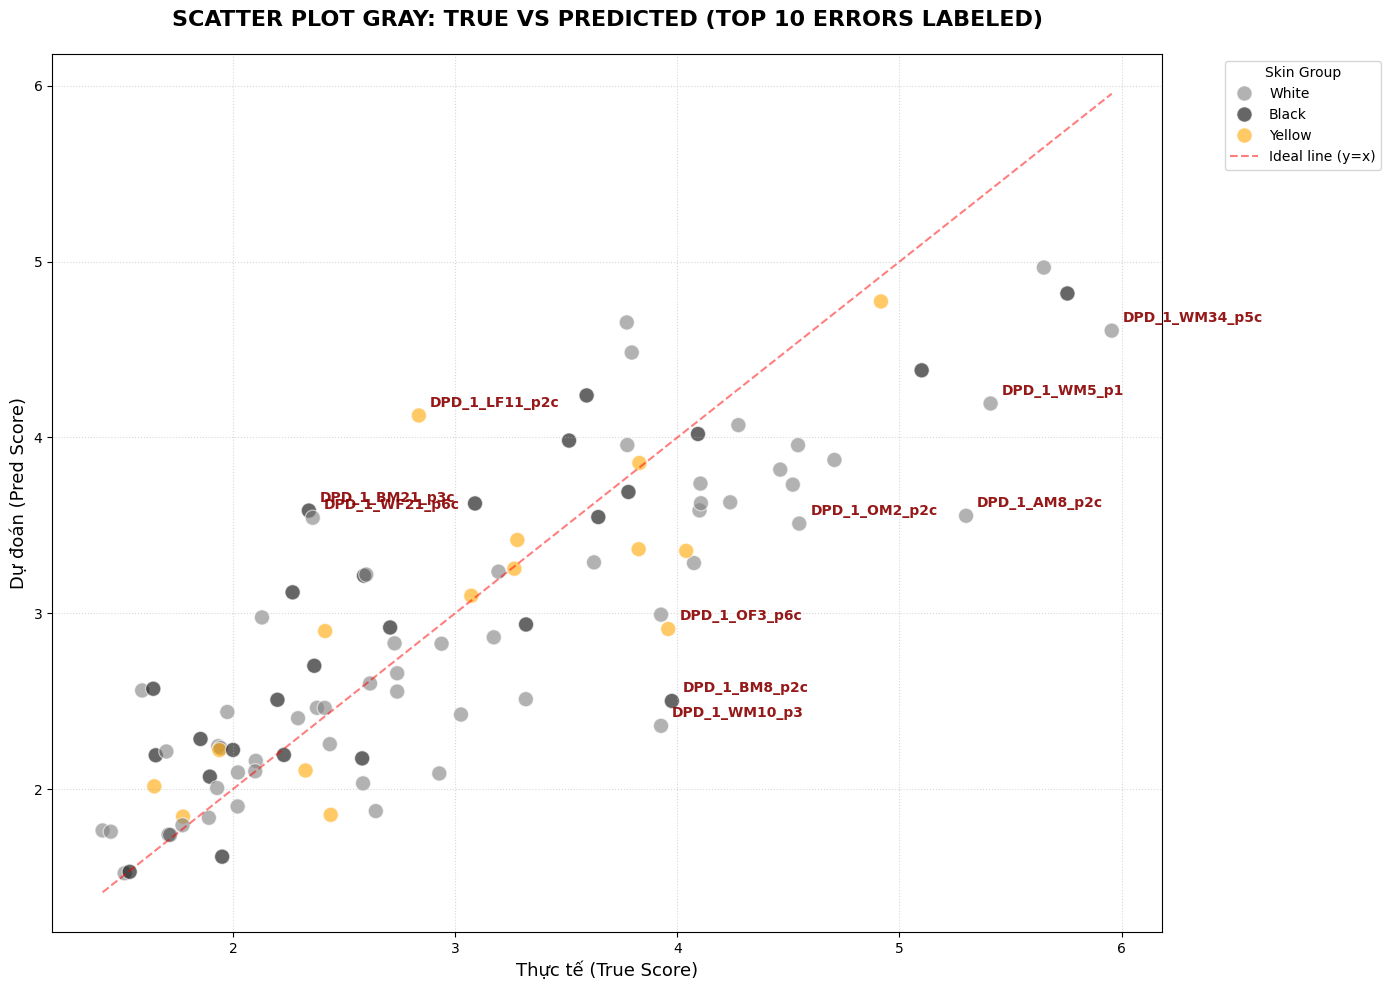

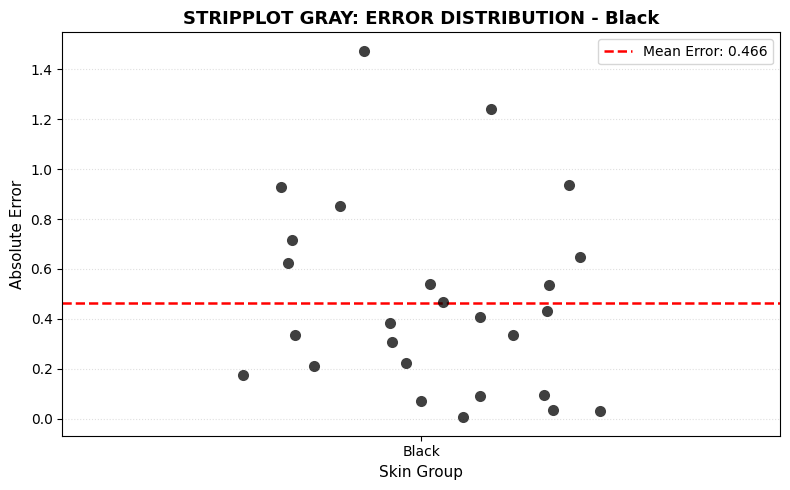

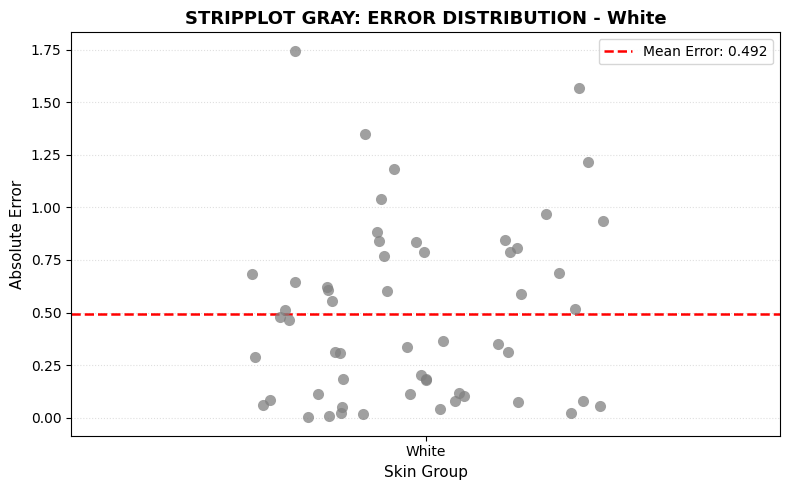

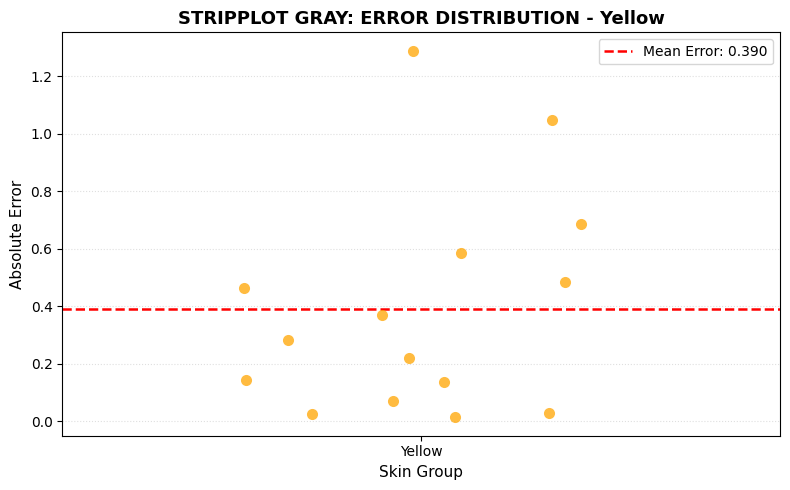


 🔍 DANH SÁCH CHI TIẾT TOP 10 ẢNH CÓ SAI SỐ (ERROR) CAO NHẤT:


,Image,ColorGroup,TrueScore,PredScore,Error
0,DPD_1_AM8_p2c.png,White,5.3000,3.554582,1.745418
1,DPD_1_WM10_p3.png,White,3.9268,2.359692,1.567108
2,DPD_1_BM8_p2c.png,Black,3.9756,2.501161,1.474439
3,DPD_1_WM34_p5c.png,White,5.9556,4.607782,1.347818
4,DPD_1_LF11_p2c.png,Yellow,2.8367,4.125392,1.288692
5,DPD_1_BM21_p3c.png,Black,2.3415,3.584192,1.242692
6,DPD_1_WM5_p1.png,White,5.4103,4.193244,1.217056
7,DPD_1_WF21_p6c.png,White,2.3590,3.543319,1.184319
8,DPD_1_OF3_p6c.png,Yellow,3.9592,2.910633,1.048567
9,DPD_1_OM2_p2c.png,White,4.5490,3.510172,1.038828


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_scatter_with_top_10_labels(df):
    plt.figure(figsize=(14, 10))

    # 1. Vẽ các điểm dữ liệu chính
    sns.scatterplot(
        data=df,
        x='TrueScore', y='PredScore',
        hue='ColorGroup',
        palette={'Black': 'black', 'White': 'gray', 'Yellow': 'orange'},
        alpha=0.6,
        s=120,
        edgecolor='w'
    )

    # 2. Vẽ đường dự đoán lý tưởng (y=x)
    max_v = max(df['TrueScore'].max(), df['PredScore'].max())
    min_v = min(df['TrueScore'].min(), df['PredScore'].min())
    plt.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', alpha=0.5, label='Ideal line (y=x)')

    # 3. XÁC ĐỊNH TOP 10 ẢNH SAI SỐ LỚN NHẤT ĐỂ HIỆN TÊN
    top_10 = df.nlargest(10, 'Error')

    # Ghi tên lên scatter
    for _, row in top_10.iterrows():
        clean_name = row['Image'].replace('.png', '')
        plt.text(
            row['TrueScore'] + 0.05,
            row['PredScore'] + 0.05,
            clean_name,
            fontsize=10,
            fontweight='bold',
            color='darkred',
            alpha=0.9
        )

    # 4. Trang trí biểu đồ
    plt.title("SCATTER PLOT GRAY: TRUE VS PREDICTED (TOP 10 ERRORS LABELED)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Thực tế (True Score)', fontsize=13)
    plt.ylabel('Dự đoán (Pred Score)', fontsize=13)
    plt.legend(title='Skin Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_stripplot_by_skin_group(df):
    palette = {'Black': 'black', 'White': 'gray', 'Yellow': 'orange'}

    for group in ['Black', 'White', 'Yellow']:
        dg = df[df['ColorGroup'] == group]
        if dg.empty:
            continue

        plt.figure(figsize=(8, 5))
        sns.stripplot(
            data=dg,
            x='ColorGroup',
            y='Error',
            color=palette[group],
            jitter=0.25,
            size=8,
            alpha=0.75
        )

        mean_err = dg['Error'].mean()
        plt.axhline(mean_err, color='red', linestyle='--', linewidth=1.8, label=f'Mean Error: {mean_err:.3f}')

        plt.title(f"STRIPPLOT GRAY: ERROR DISTRIBUTION - {group}", fontsize=13, fontweight='bold')
        plt.xlabel('Skin Group', fontsize=11)
        plt.ylabel('Absolute Error', fontsize=11)
        plt.grid(True, axis='y', linestyle=':', alpha=0.4)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()


# THỰC THI (Hiển thị đồng thời cả Đồ thị và Bảng)
if 'df_r' in locals() and not df_r.empty:
    # Vẽ Biểu đồ scatter
    plot_scatter_with_top_10_labels(df_r)

    # Vẽ 3 stripplot cho từng nhóm màu da
    plot_stripplot_by_skin_group(df_r)

    # Hiển thị List bên dưới
    print("\n" + "="*80)
    print(" 🔍 DANH SÁCH CHI TIẾT TOP 10 ẢNH CÓ SAI SỐ (ERROR) CAO NHẤT:")
    print("="*80)
    display(df_r.nlargest(10, 'Error')[['Image', 'ColorGroup', 'TrueScore', 'PredScore', 'Error']])
else:
    print("⚠️ Dữ liệu 'df_r' chưa sẵn sàng. Vui lòng chạy cell phân tích Group ở trên trước nhé.")